In [1]:
import pandas as pd
import sys
import os
import re
import numpy as np

In [2]:
sys.path.append(os.path.abspath("../.."))
%pip install matplotlib
%pip install scikit-learn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from ai.utils.integral import Integral
from ai.utils.printer import Printer
from ai.utils.expr.expr_node import ExprNode
from ai.utils.expr.trig.expr_sin import SinExprNode 
from ai.utils.expr.trig.expr_cos import CosExprNode
from ai.utils.expr.trig.expr_tan import TanExprNode
from ai.utils.expr.operation.expr_add import AddExprNode
from ai.utils.expr.operation.expr_sub import SubExprNode
from ai.utils.expr.operation.expr_mul import MulExprNode
from ai.utils.expr.operation.expr_frac import FracExprNode  
from ai.utils.expr.value.expr_var import VarExprNode
from ai.utils.expr.value.expr_const import ConstExprNode
from ai.utils.expr.Power.expr_mono import MonoExprNode
from ai.utils.expr.expr_log import LogExprNode
from ai.utils.expr.Power.expr_sqrt import SqrtExprNode
from ai.utils.expr.Power.expr_power import PowerExprNode

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("../data/processed/integral_dataset.csv")

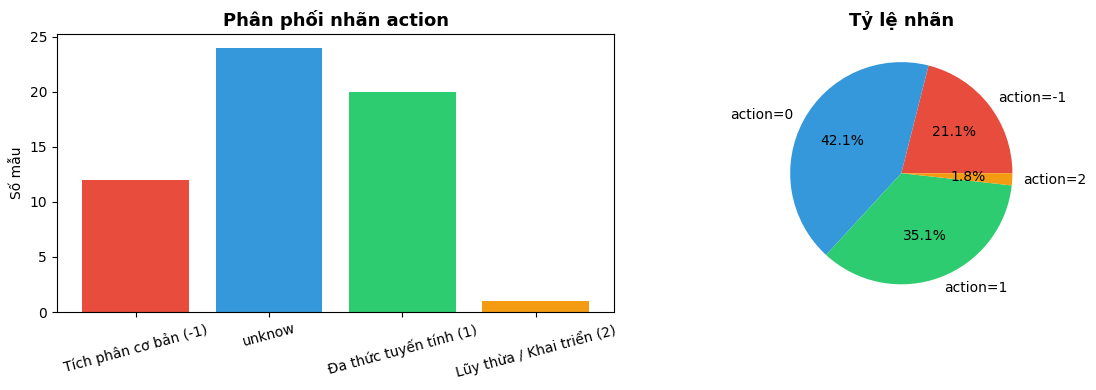

In [4]:
from collections import Counter
y = df['label']
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_names = {-1: 'Tích phân cơ bản (-1)', 
                0: 'unknow', 
                1: 'Đa thức tuyến tính (1)', 
                2: 'Lũy thừa / Khai triển (2)'}
counts = Counter(y)
labels = sorted(counts.keys())
values = [counts[l] for l in labels]
names  = [label_names.get(l, str(l)) for l in labels]

axes[0].bar(names, values, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0].set_title('Phân phối nhãn action', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số mẫu')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(values, labels=[f'action={l}' for l in labels], autopct='%1.1f%%',
            colors=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[1].set_title('Tỷ lệ nhãn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
X = df.drop(columns=['label'])

class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
cw_dict = dict(zip(np.unique(y), class_weights))
print('⚖️  Class weights:', cw_dict)

# Train/test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f'\n🔀 Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

⚖️  Class weights: {-1: 1.1875, 0: 0.59375, 1: 0.7125, 2: 14.25}

🔀 Train: 45 | Test: 12


In [6]:
# Pipeline: StandardScaler + SVM
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

# Grid search parameters
param_grid = [
    {
        'svm__kernel': ['rbf'],
        'svm__C':      [0.1, 1, 10, 100],
        'svm__gamma':  ['scale', 'auto', 0.01, 0.1]
    },
    {
        'svm__kernel': ['linear'],
        'svm__C':      [0.1, 1, 10]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C':      [0.1, 1, 10],
        'svm__degree': [2, 3]
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svm_pipeline, param_grid, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)

print('🔍 Đang chạy GridSearchCV...')
grid_search.fit(X_train, y_train)

print(f'\n🏆 Best params: {grid_search.best_params_}')
print(f'🏆 Best CV F1 (macro): {grid_search.best_score_:.4f}')

🔍 Đang chạy GridSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


c:\Users\giaba\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



🏆 Best params: {'svm__C': 100, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
🏆 Best CV F1 (macro): 0.4670
